In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [5]:
df = yf.download("^NSEI", start="2010-01-01")
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2026-04-28  23995.699219  24181.800781  23957.050781  24049.900391  554100
2026-04-29  24177.650391  24334.699219  24059.949219  24096.900391  531100
2026-04-30  23997.550781  24087.449219  23796.849609  23996.949219  505500
2026-05-04  24119.300781  24290.199219  24004.750000  24063.550781  419100
2026-05-05  24032.800781  24081.699219  23882.050781  24052.599609  363300


In [ ]:
df.columns = ["Close", "High", "Low", "Open", "Volume"]


DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24',
               '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30',
               '2026-05-04', '2026-05-05'],
              dtype='datetime64[s]', name='Date', length=4010, freq=None)

count    4009.000000
mean        0.000435
std         0.010422
min        -0.129805
25%        -0.004840
50%         0.000588
75%         0.006110
max         0.087632
Name: return, dtype: float64

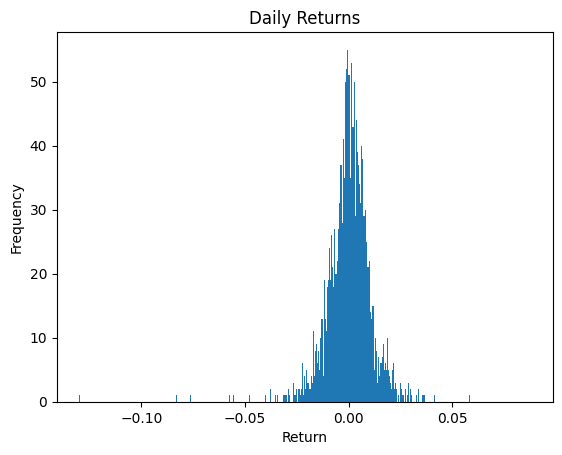

In [ ]:
df["return"] = df["Close"]/df["Close"].shift(1) - 1
plt.hist(df["return"],bins=1000)
plt.title("Daily Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
df["return"].describe()



In [22]:
df_ohlc = df["Close"].resample("ME").ohlc()
df_ohlc.describe()

,open,high,low,close
count,197.000000,197.000000,197.000000,197.000000
mean,12094.045722,12447.562458,11776.948517,12164.468785
std,6452.775191,6602.438552,6323.140858,6473.842549
min,4765.299805,4931.850098,4544.200195,4624.299805
25%,6221.450195,6363.899902,6139.049805,6304.000000
50%,10211.799805,10471.000000,9998.049805,10302.099609
75%,17340.050781,17855.099609,16887.349609,17303.949219
max,26175.750000,26328.550781,25758.000000,26202.949219


In [39]:

df_std = df["return"].groupby(df.index.year).std() * (252**0.5)
print(df_std)
print(df_std.nlargest(5))

Date
2010    0.163200
2011    0.211865
2012    0.155362
2013    0.181721
2014    0.128097
2015    0.163531
2016    0.151947
2017    0.090289
2018    0.128838
2019    0.139415
2020    0.313290
2021    0.156535
2022    0.173275
2023    0.098153
2024    0.140640
2025    0.118111
2026    0.183295
Name: return, dtype: float64
Date
2020    0.313290
2011    0.211865
2026    0.183295
2013    0.181721
2022    0.173275
Name: return, dtype: float64


Date
2020-04-07    0.087632
2020-03-25    0.066247
2020-03-20    0.058329
2019-09-20    0.053191
2021-02-01    0.047424
Name: return, dtype: float64
Date
2020-03-23   -0.129805
2020-03-12   -0.083019
2020-03-16   -0.076121
2024-06-04   -0.059294
2015-08-24   -0.059151
Name: return, dtype: float64


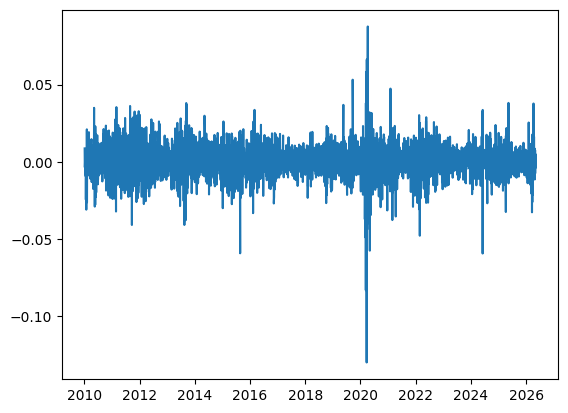

In [40]:
plt.plot(df.index, df["return"])
print(df["return"].nlargest(5))
print(df["return"].nsmallest(5))

#Observations:

1. biggest range in std was in year 2020 because of the covid pandemic.
2. anual std for each year sits around 0.15 but we have seen years with alot more than that 2020, 2011 and 2026 and its not over yet
3. It was amazing to see a simple 1% std becomes more than 15% annually thats a lot
4. it was surprsing to see that top 3 returns positive and negative to be in a single year of 2020
